In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
import pandas as pd

data = pd.read_csv("HomeC.xls")

data.columns = data.columns.str.strip()

print("Dataset loaded successfully")
print("Shape:", data.shape)

data.head()

Dataset loaded successfully
Shape: (108793, 32)


C:\Users\DELL\AppData\Local\Temp\ipykernel_228\1926119625.py:3: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("HomeC.xls")


,time,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],...,visibility,summary,apparentTemperature,pressure,windSpeed,cloudCover,windBearing,precipIntensity,dewPoint,precipProbability
0,1451624400,0.932833,0.003483,0.932833,0.000033,0.020700,0.061917,0.442633,0.124150,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
1,1451624401,0.934333,0.003467,0.934333,0.000000,0.020717,0.063817,0.444067,0.124000,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2,1451624402,0.931817,0.003467,0.931817,0.000017,0.020700,0.062317,0.446067,0.123533,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
3,1451624403,1.022050,0.003483,1.022050,0.000017,0.106900,0.068517,0.446583,0.123133,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
4,1451624404,1.139400,0.003467,1.139400,0.000133,0.236933,0.063983,0.446533,0.122850,0.006850,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0


In [4]:
data[data.columns[0]] = pd.to_datetime(data[data.columns[0]], errors="coerce")

data.set_index(data.columns[0], inplace=True)

data.head()

,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],Garage door [kW],...,visibility,summary,apparentTemperature,pressure,windSpeed,cloudCover,windBearing,precipIntensity,dewPoint,precipProbability
time,,,,,,,,,,,,,,,,,,,,,
1970-01-01 00:00:01.451624400,0.932833,0.003483,0.932833,0.000033,0.020700,0.061917,0.442633,0.124150,0.006983,0.013083,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
1970-01-01 00:00:01.451624401,0.934333,0.003467,0.934333,0.000000,0.020717,0.063817,0.444067,0.124000,0.006983,0.013117,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
1970-01-01 00:00:01.451624402,0.931817,0.003467,0.931817,0.000017,0.020700,0.062317,0.446067,0.123533,0.006983,0.013083,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
1970-01-01 00:00:01.451624403,1.022050,0.003483,1.022050,0.000017,0.106900,0.068517,0.446583,0.123133,0.006983,0.013000,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
1970-01-01 00:00:01.451624404,1.139400,0.003467,1.139400,0.000133,0.236933,0.063983,0.446533,0.122850,0.006850,0.012783,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0


In [21]:
numeric_data = data.select_dtypes(include="number")

print("Numeric columns selected")

Numeric columns selected


In [22]:
hourly_data = numeric_data.resample("h").mean()

print("Hourly data created successfully")

hourly_data.head()

Hourly data created successfully


,gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],Garage door [kW],Kitchen 12 [kW],...,temperature,humidity,visibility,apparentTemperature,pressure,windSpeed,windBearing,precipIntensity,dewPoint,precipProbability
use [kW],,,,,,,,,,,,,,,,,,,,,
1970-01-01,0.066935,0.956471,0.033798,0.192918,0.221994,0.078773,0.053771,0.020883,0.01371,0.002332,...,32.241536,0.618106,9.261053,26.442571,1015.549263,7.697786,211.146978,0.002676,19.763517,0.056085


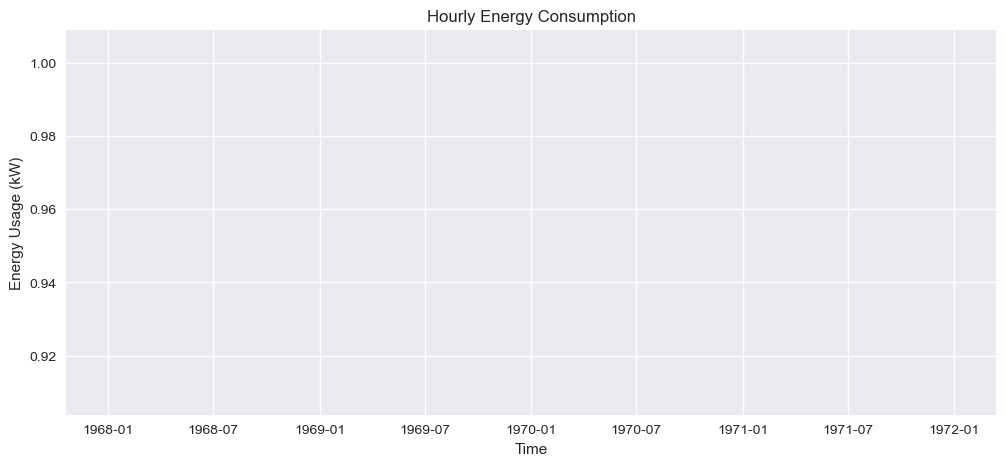

In [37]:
plt.figure(figsize=(12,5))

plt.plot(hourly_data["House overall [kW]"], color="blue")

plt.title("Hourly Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Energy Usage (kW)")

plt.grid(True)

plt.show()

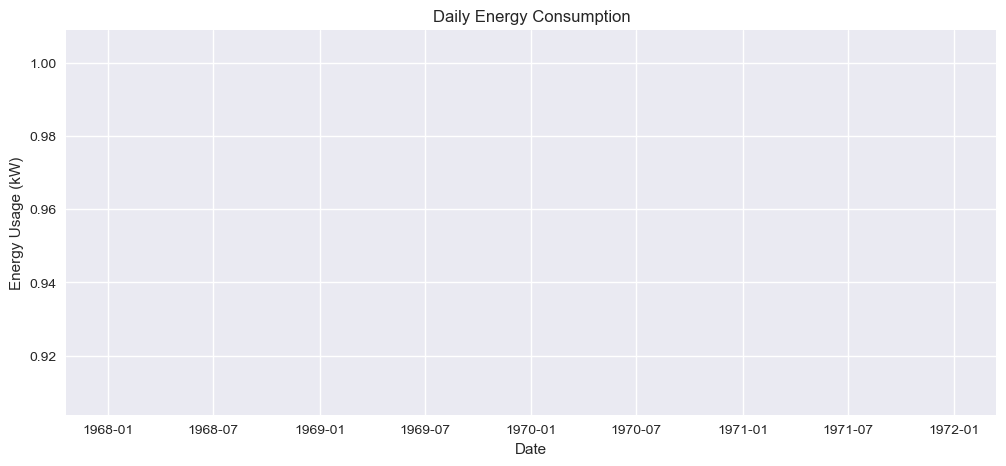

In [38]:
daily_data = numeric_data.resample("D").mean()

plt.figure(figsize=(12,5))

plt.plot(daily_data["House overall [kW]"], color="green")

plt.title("Daily Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Energy Usage (kW)")

plt.grid(True)

plt.show()

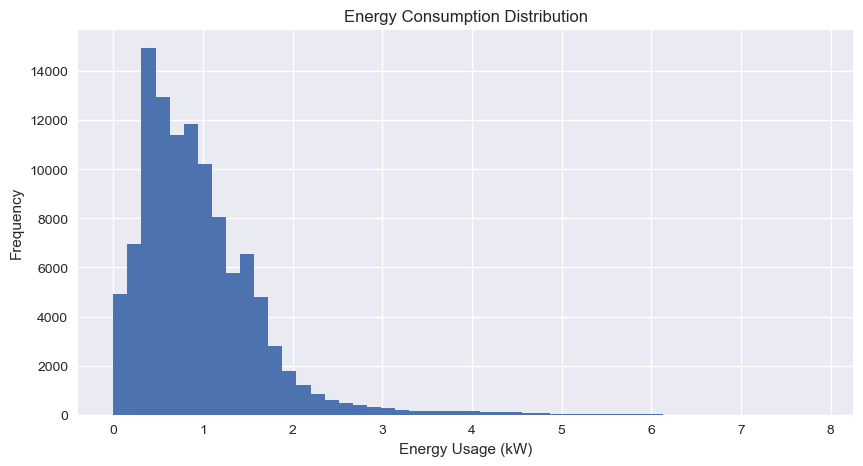

In [39]:
plt.figure(figsize=(10,5))

plt.hist(numeric_data["House overall [kW]"].dropna(), bins=50)

plt.title("Energy Consumption Distribution")
plt.xlabel("Energy Usage (kW)")
plt.ylabel("Frequency")

plt.show()

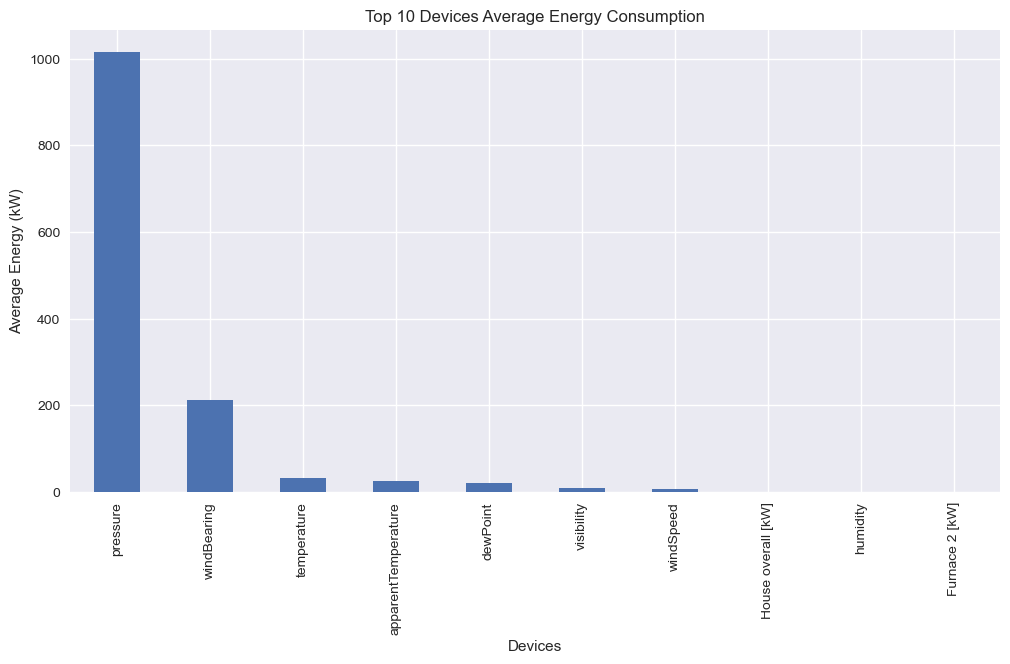

In [42]:
device_mean = numeric_data.mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

device_mean.head(10).plot(kind="bar")

plt.title("Top 10 Devices Average Energy Consumption")
plt.xlabel("Devices")
plt.ylabel("Average Energy (kW)")

plt.show()

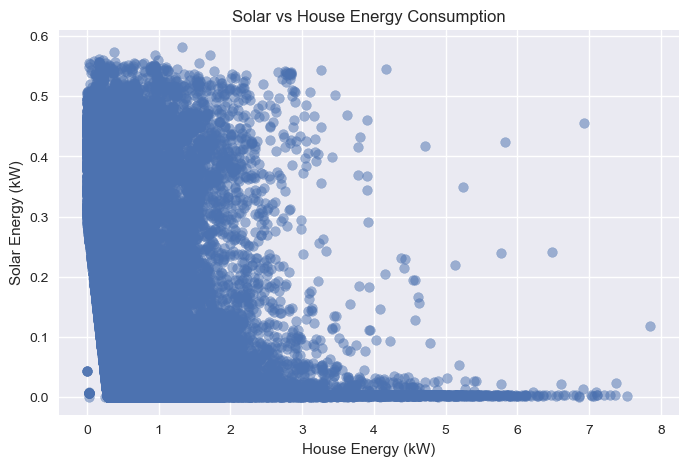

In [49]:
plt.figure(figsize=(8,5))

plt.scatter(
    numeric_data["House overall [kW]"],
    numeric_data["Solar [kW]"],
    alpha=0.5
)

plt.title("Solar vs House Energy Consumption")
plt.xlabel("House Energy (kW)")
plt.ylabel("Solar Energy (kW)")

plt.show()

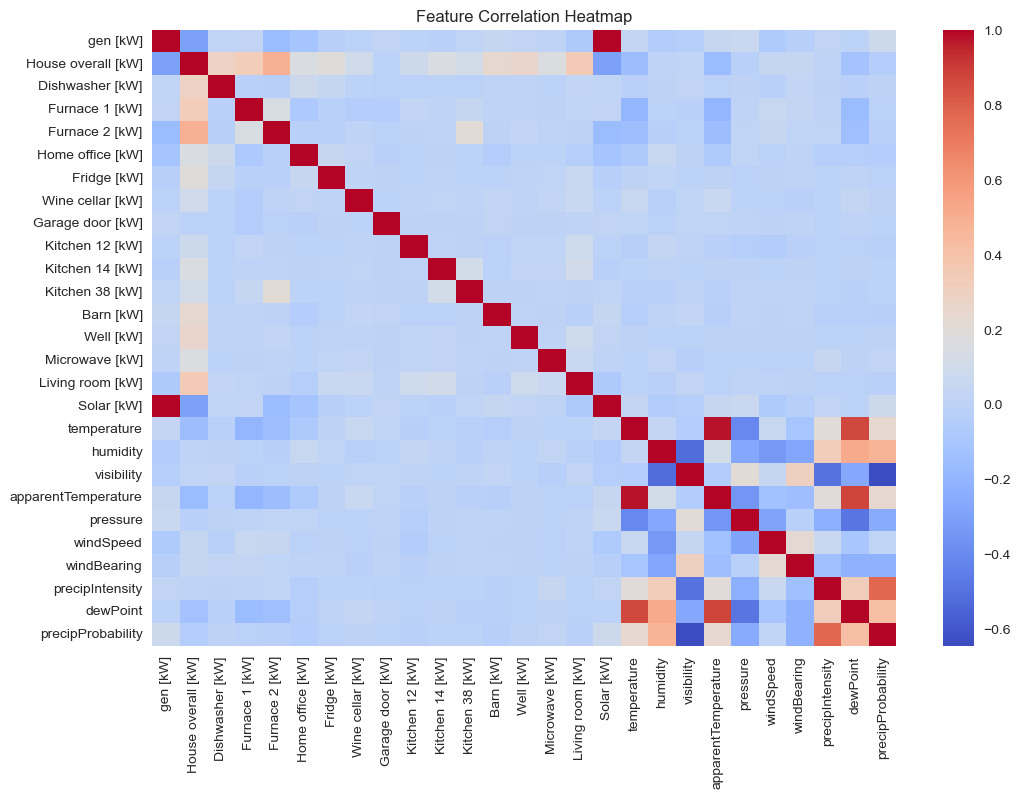

In [48]:
import seaborn as sns

plt.figure(figsize=(12,8))

corr = numeric_data.corr()

sns.heatmap(corr, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

In [50]:
print("Final processed dataset shape:", hourly_data.shape)

hourly_data.describe()

Final processed dataset shape: (1, 27)


,gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],Garage door [kW],Kitchen 12 [kW],...,temperature,humidity,visibility,apparentTemperature,pressure,windSpeed,windBearing,precipIntensity,dewPoint,precipProbability
count,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
mean,0.066935,0.956471,0.033798,0.192918,0.221994,0.078773,0.053771,0.020883,0.01371,0.002332,...,32.241536,0.618106,9.261053,26.442571,1015.549263,7.697786,211.146978,0.002676,19.763517,0.056085
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.066935,0.956471,0.033798,0.192918,0.221994,0.078773,0.053771,0.020883,0.01371,0.002332,...,32.241536,0.618106,9.261053,26.442571,1015.549263,7.697786,211.146978,0.002676,19.763517,0.056085
25%,0.066935,0.956471,0.033798,0.192918,0.221994,0.078773,0.053771,0.020883,0.01371,0.002332,...,32.241536,0.618106,9.261053,26.442571,1015.549263,7.697786,211.146978,0.002676,19.763517,0.056085
50%,0.066935,0.956471,0.033798,0.192918,0.221994,0.078773,0.053771,0.020883,0.01371,0.002332,...,32.241536,0.618106,9.261053,26.442571,1015.549263,7.697786,211.146978,0.002676,19.763517,0.056085
75%,0.066935,0.956471,0.033798,0.192918,0.221994,0.078773,0.053771,0.020883,0.01371,0.002332,...,32.241536,0.618106,9.261053,26.442571,1015.549263,7.697786,211.146978,0.002676,19.763517,0.056085
max,0.066935,0.956471,0.033798,0.192918,0.221994,0.078773,0.053771,0.020883,0.01371,0.002332,...,32.241536,0.618106,9.261053,26.442571,1015.549263,7.697786,211.146978,0.002676,19.763517,0.056085


In [52]:
X = numeric_data

y = numeric_data["House overall [kW]"]

print("Features and target prepared")

Features and target prepared


In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (87034, 27)
Testing Data Shape: (21759, 27)
